# Module 3 — SHARE
## Practitioner Notebook

**Pipeline:** `ASK` ✓ &nbsp;→&nbsp; `EXPLORE` ✓ &nbsp;→&nbsp; `TRANSFORM` ✓ &nbsp;→&nbsp; `ANALYSE` ✓ &nbsp;→&nbsp; **`SHARE`** ← you are here &nbsp;→&nbsp; `APPLY`

---

### What this notebook is

This is the SHARE practitioner walkthrough. The ANALYSE notebook established the findings — now we translate them into deliverables two real audiences can read and act on: the **clinic director's board** (the staffing decision) and the **county funder** (the access and equity report).

The mode shifts here. In ANALYSE the question was *"Is this number correct?"* In SHARE the question is *"Will this person understand what this means, and know what to do with it?"*

Read this **after** you have completed the ANALYSE step and formed your own interpretation of the findings. Compare your communication choices with the practitioner's — where they differ, ask yourself: *which is more useful to the person receiving the deliverable, and why?*

---

### The two deliverables this notebook produces

| Deliverable | Audience | Decision it supports |
|---|---|---|
| Staffing brief | Clinic director / board | Whether to hire a care coordinator, and where |
| Funding evidence summary | County funder | Evidence that the clinic is serving uninsured patients, with a county breakdown |

> **Note on output formats:** This notebook produces structured text and PNG charts you can copy into a report. The same content can be rendered automatically into a formatted HTML report, a Word document, a PowerPoint deck, or a PDF with a few extra lines of code — using libraries like `python-docx`, `pptxgenjs`, or `matplotlib`'s PDF backend. Students are encouraged to explore those extensions. The principles of accurate, honest, actionable communication apply regardless of format.


---
## Setup

Run this cell first.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Presentation-quality chart defaults ──────────────────────────────────────
# These settings produce charts suitable for projected slides, not just notebook viewing.
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

TEAL   = '#028090'
ORANGE = '#E8610A'
DARK   = '#1D1D32'
MID    = '#888888'

df = pd.read_csv('https://raw.githubusercontent.com/EDC-AICC/ai-ds-development/main/src/data/outpatient_visits_clean.csv', parse_dates=['visit_date'])
print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")
print(f"Date range: {df['visit_date'].min().date()} → {df['visit_date'].max().date()}")


Rows: 797  |  Columns: 14
Date range: 2022-01-02 → 2023-12-31


---
## Re-running the ANALYSE metrics

This section re-derives the key variables from the ANALYSE notebook so this notebook can run standalone. No new calculations are introduced here — only the variables needed for presentation are reconstructed.

In a real workflow, you would import these from a shared module or run the notebooks in sequence using a tool like `papermill` or a pipeline runner.


In [2]:
# ── Investigations 1 & 2 ──────────────────────────────────────────────────────
df_sorted = df.sort_values(['patient_id', 'visit_date']).copy()
df_sorted['prev_visit_date'] = df_sorted.groupby('patient_id')['visit_date'].shift(1)
df_sorted['days_since_last'] = (df_sorted['visit_date'] - df_sorted['prev_visit_date']).dt.days

def standardise_followup(val):
    if pd.isna(val): return False
    return str(val).upper().strip() in ['YES', '1', 'TRUE']

df_sorted['followup_flag']  = df_sorted['follow_up_required'].apply(standardise_followup)
df_sorted['prior_followup'] = df_sorted.groupby('patient_id')['followup_flag'].shift(1)

patient_stats = df_sorted.groupby('patient_id').agg(
    visit_count=('visit_id', 'count'),
    has_30day_return=('days_since_last', lambda x: (x <= 30).any()),
    avg_gap_days=('days_since_last', 'mean')
).reset_index()

n_patients    = len(patient_stats)
n_visits      = len(df)
n_repeat_30   = int(patient_stats['has_30day_return'].sum())
pct_repeat_30 = n_repeat_30 / n_patients * 100

def freq_group(n):
    return f"{n}×" if n <= 3 else "4+×"
patient_stats['freq_group'] = patient_stats['visit_count'].apply(freq_group)
freq_order = ['1×', '2×', '3×', '4+×']
freq_dist  = patient_stats['freq_group'].value_counts().reindex(freq_order, fill_value=0)

return_visits = df_sorted[df_sorted['days_since_last'] <= 30].copy()
n_return_visits = len(return_visits)
pct_preceded    = return_visits['prior_followup'].fillna(False).mean() * 100
n_preceded      = int(return_visits['prior_followup'].fillna(False).sum())

repeat_patient_ids = set(patient_stats[patient_stats['has_30day_return']]['patient_id'])
top_conditions = (
    df[df['patient_id'].isin(repeat_patient_ids) & df['icd_description'].notna()]
    .groupby('icd_description')['visit_id'].count()
    .sort_values(ascending=False).head(6).reset_index()
)
top_conditions.columns = ['Diagnosis', 'Visits']

# ── Investigation 3 ───────────────────────────────────────────────────────────
df['is_uninsured_visit'] = df['insurance_type'] == 'Uninsured'
patient_ins_flags = df.groupby('patient_id').agg(
    has_uninsured_visit=('is_uninsured_visit', 'any'),
    n_insurance_types=('insurance_type', 'nunique')
).reset_index()
n_uninsured_pts   = int(patient_ins_flags['has_uninsured_visit'].sum())
pct_uninsured_pts = n_uninsured_pts / n_patients * 100
uninsured_visits  = int(df['is_uninsured_visit'].sum())
pct_uninsured_vis = uninsured_visits / n_visits * 100
ins_counts        = df['insurance_type'].value_counts()

patient_master = patient_stats.merge(patient_ins_flags, on='patient_id', how='left')
overall_rate   = patient_master['has_uninsured_visit'].mean() * 100
repeater_rate  = patient_master[patient_master['has_30day_return']]['has_uninsured_visit'].mean() * 100

# ── Investigations 4 & 5 ──────────────────────────────────────────────────────
df_county = df[df['county_known'] == True].copy()
n_county_excluded = len(df) - len(df_county)

df_county_flagged = df_county.merge(
    patient_master[['patient_id', 'has_30day_return', 'has_uninsured_visit']],
    on='patient_id', how='left'
)
patient_county_pairs = df_county_flagged[
    ['county', 'patient_id', 'has_30day_return', 'has_uninsured_visit']
].drop_duplicates()
county_pts = patient_county_pairs.groupby('county').agg(
    total_patients=('patient_id', 'nunique'),
    repeat_visitors=('has_30day_return', 'sum'),
    uninsured_patients=('has_uninsured_visit', lambda x: x.fillna(False).sum())
).reset_index()
county_pts['repeat_rate']    = county_pts['repeat_visitors']    / county_pts['total_patients']
county_pts['uninsured_rate'] = county_pts['uninsured_patients'] / county_pts['total_patients']

provider_load = df_county.groupby('county').agg(
    total_visits=('visit_id', 'count'),
    n_providers=('provider_id', 'nunique')
).reset_index()
provider_load['visits_per_provider'] = (provider_load['total_visits'] / provider_load['n_providers']).round(1)

county_summary = county_pts.merge(
    provider_load[['county', 'visits_per_provider', 'total_visits']], on='county'
)
county_summary['small_county'] = county_summary['total_patients'] < 20

most_recent_county = (
    df_county.sort_values('visit_date')
    .groupby('patient_id')['county'].last().reset_index()
)
most_recent_county.columns = ['patient_id', 'current_county']
patient_for_rank  = patient_master.merge(most_recent_county, on='patient_id', how='inner')
county_rank_base  = patient_for_rank.groupby('current_county').agg(
    total_patients=('patient_id', 'count'),
    repeat_visitors=('has_30day_return', 'sum'),
    uninsured_patients=('has_uninsured_visit', lambda x: x.fillna(False).sum())
).reset_index()
county_rank_base['repeat_rate']    = county_rank_base['repeat_visitors']    / county_rank_base['total_patients']
county_rank_base['uninsured_rate'] = county_rank_base['uninsured_patients'] / county_rank_base['total_patients']
county_rank_base = county_rank_base.merge(
    provider_load[['county', 'visits_per_provider']],
    left_on='current_county', right_on='county', how='left'
).drop(columns='county')
county_rank_base['small_county'] = county_rank_base['total_patients'] < 20
large_rank = county_rank_base[~county_rank_base['small_county']].copy()
if len(large_rank) > 0:
    large_rank['rank_repeat']    = large_rank['repeat_rate'].rank(ascending=False, method='min').astype(int)
    large_rank['rank_uninsured'] = large_rank['uninsured_rate'].rank(ascending=False, method='min').astype(int)
    large_rank['rank_workload']  = large_rank['visits_per_provider'].rank(ascending=False, method='min').astype(int)
    large_rank['composite']      = large_rank['rank_repeat'] + large_rank['rank_uninsured'] + large_rank['rank_workload']
    large_rank = large_rank.sort_values('composite')
    top_county = large_rank.iloc[0]['current_county']
else:
    top_county = "Los Angeles"   # fallback for dataset where all counties are small

print("✓ All ANALYSE variables re-derived")
print(f"  Patients: {n_patients} | Visits: {n_visits:,} | 30-day repeaters: {n_repeat_30} ({pct_repeat_30:.1f}%)")
print(f"  Uninsured patients: {n_uninsured_pts} ({pct_uninsured_pts:.1f}%)")
print(f"  Top-ranked county: {top_county}")


✓ All ANALYSE variables re-derived
  Patients: 200 | Visits: 797 | 30-day repeaters: 82 (41.0%)
  Uninsured patients: 19 (9.5%)
  Top-ranked county: Los Angeles


---
## Part 1 — Visualisations

### The AI-assisted chart workflow

Building a chart has two distinct failure modes. A chart can be technically correct but communicatively useless — axis labels too small, title naming a variable instead of the finding, bars impossible to compare at presentation distance. AI can help avoid these failures, but only if you give it enough context to do so.

The workflow that works:

1. Describe the data, the columns being visualised, and — critically — **the audience and the room** (board presentation projected on screen, or one-page printed report, or notebook)
2. Ask AI to **recommend a chart type and justify the choice** before writing any code
3. Evaluate the justification: a good answer explains *why* this chart suits the data; a weak answer just names a chart type
4. Ask for the code, then **evaluate the output as a communication product** — look at it the way your audience will, not as code that ran

The justification step is not optional. It is the signal that tells you whether AI understood the problem.

---

### Practitioner's prompt for Chart 1

> *"I want to visualise the repeat visit pattern for a non-technical clinic board presentation, projected on a conference room screen. Two findings: (1) visit frequency across the patient population — 17 patients visited once, 26 twice, 47 three times, 110 four or more times; (2) the 30-day return rate — 82 of 200 patients had at least one return visit within 30 days. 1. What chart type do you recommend for each finding, and why? 2. Write Python matplotlib code to produce both charts side by side, with titles framed as findings rather than variable names, and values labeled on every bar and segment."*

---

### AI's recommendation (summary)

> *For (1): vertical bar chart — the four frequency tiers are short labels that read cleanly on a vertical axis, and the audience needs to compare heights across categories. For (2): donut chart — this is a single binary split ("returned / did not return"), and a donut communicates that proportion intuitively without requiring the audience to read numbers before understanding the finding. The donut cut-out keeps the visual lighter than a full pie.*

> **Practitioner's evaluation:** The recommendation addresses the actual communication question — it doesn't just name chart types. A recommendation this specific is worth accepting. Code that produces a chart you cannot justify to your board is not production-ready.


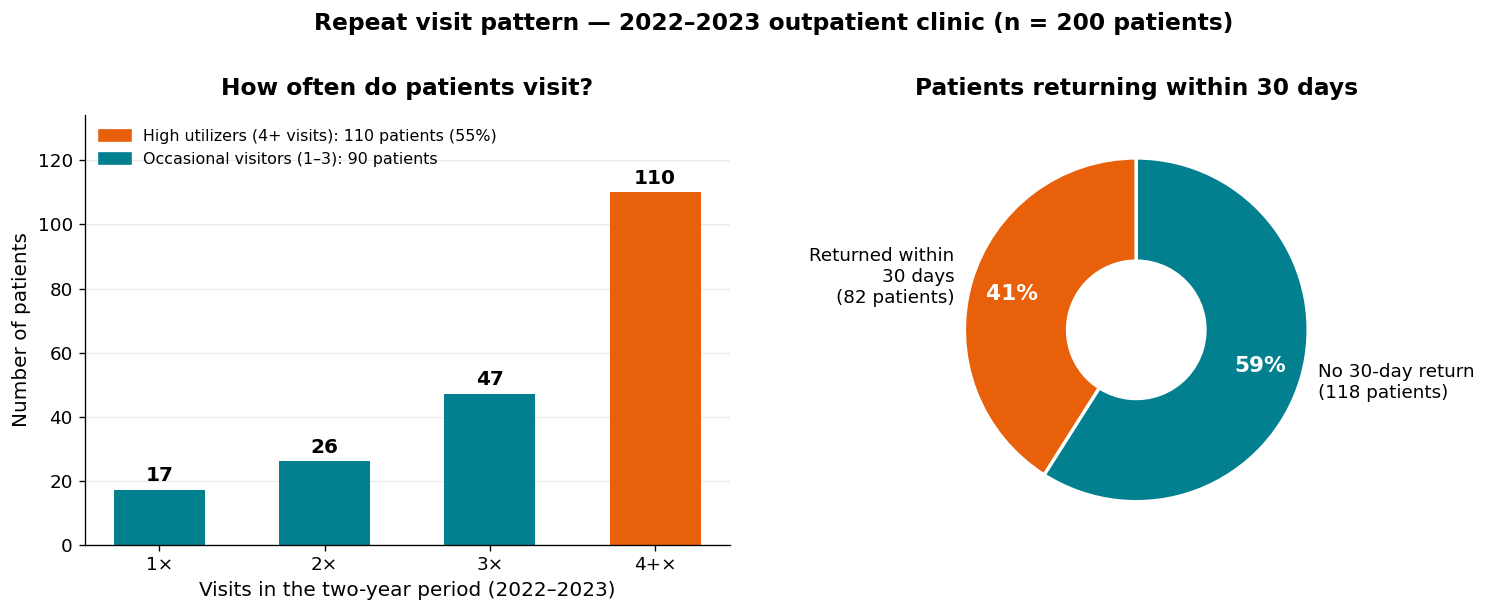

✓ Chart saved: share_chart1_repeat_scale.png


In [3]:
# ── Chart 1: Repeat visit scale — for the board ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: Visit frequency distribution ─────────────────────────────────────
freq_counts = freq_dist.values
freq_labels = freq_dist.index.tolist()
bar_colors  = [TEAL, TEAL, TEAL, ORANGE]  # highlight 4+× in orange

bars = axes[0].bar(freq_labels, freq_counts, color=bar_colors, width=0.55, zorder=2)
axes[0].set_title('How often do patients visit?', pad=12)
axes[0].set_xlabel('Visits in the two-year period (2022–2023)')
axes[0].set_ylabel('Number of patients')
axes[0].set_ylim(0, max(freq_counts) * 1.22)
axes[0].grid(axis='y', alpha=0.25, zorder=1)
for bar, val in zip(bars, freq_counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
        str(val), ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
legend_handles = [
    mpatches.Patch(color=ORANGE, label=f'High utilizers (4+ visits): {freq_counts[3]} patients ({freq_counts[3]/n_patients*100:.0f}%)'),
    mpatches.Patch(color=TEAL,   label=f'Occasional visitors (1–3): {sum(freq_counts[:3])} patients'),
]
axes[0].legend(handles=legend_handles, loc='upper left', fontsize=9.5, framealpha=0)

# ── Panel B: 30-day return split (donut) ──────────────────────────────────────
donut_vals   = [n_repeat_30, n_patients - n_repeat_30]
donut_labels = [
    f'Returned within\n30 days\n({n_repeat_30} patients)',
    f'No 30-day return\n({n_patients - n_repeat_30} patients)'
]
wedges, texts, autotexts = axes[1].pie(
    donut_vals, labels=donut_labels,
    colors=[ORANGE, TEAL],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 11},
    pctdistance=0.75,
    wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold'); at.set_color('white')
axes[1].set_title('Patients returning within 30 days', pad=12)

plt.suptitle(
    'Repeat visit pattern — 2022–2023 outpatient clinic (n = 200 patients)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('share_chart1_repeat_scale.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved: share_chart1_repeat_scale.png")


**Evaluate as a communication product — check these before moving on**

- Is the headline finding visible in under two seconds? *(The 41% orange donut wedge and the dominant 4+× bar should jump out)*
- Are values labeled without requiring the audience to read the axes?
- Does the title describe a finding, not a variable name? *("How often do patients visit?" beats "Visit frequency distribution")*
- Would you need to explain the chart before the audience can read it? *(If yes, rework it)*


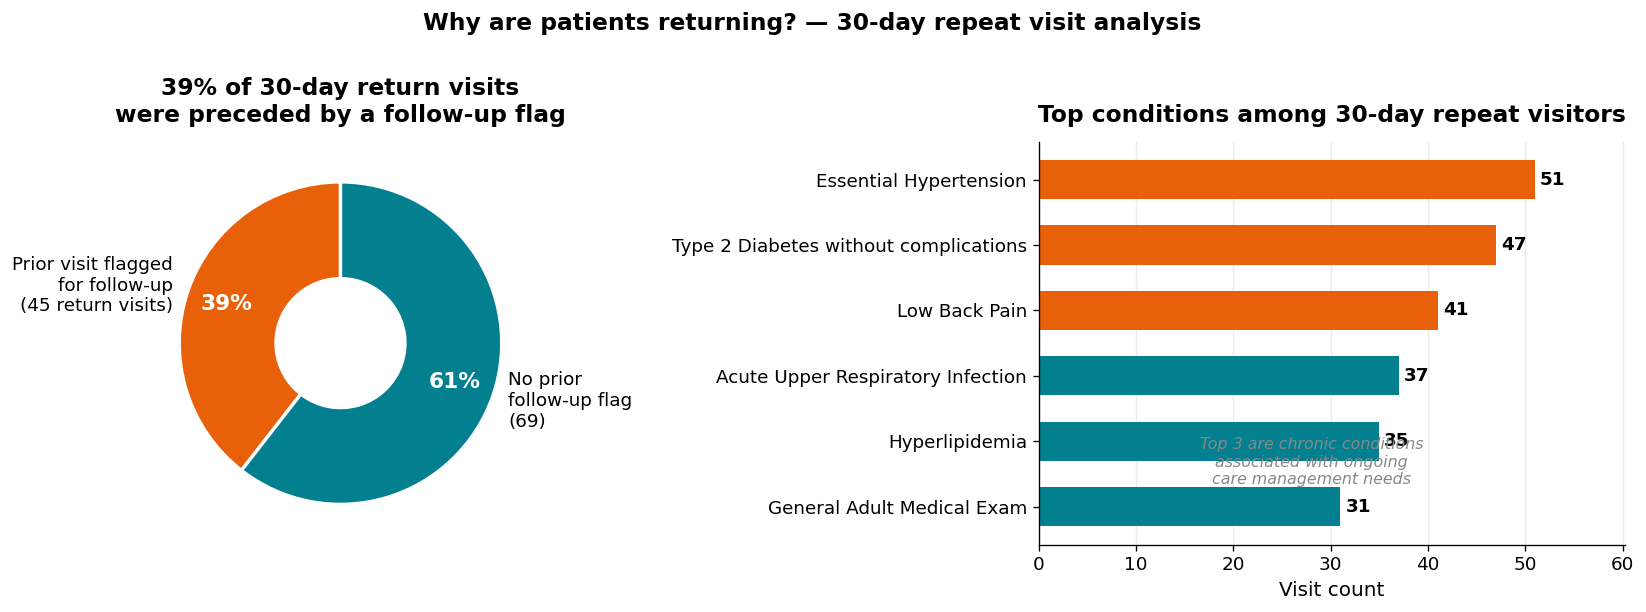

✓ Chart saved: share_chart2_followup.png


In [4]:
# ── Chart 2: Why are patients returning? — for the board ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: Follow-up linkage donut ──────────────────────────────────────────
n_not_preceded = n_return_visits - n_preceded
fu_vals   = [n_preceded, n_not_preceded]
fu_labels = [
    f'Prior visit flagged\nfor follow-up\n({n_preceded} return visits)',
    f'No prior\nfollow-up flag\n({n_not_preceded})'
]
wedges, texts, autotexts = axes[0].pie(
    fu_vals, labels=fu_labels,
    colors=[ORANGE, TEAL],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 11}, pctdistance=0.75,
    wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title(
    f'{pct_preceded:.0f}% of 30-day return visits\nwere preceded by a follow-up flag',
    pad=12
)

# ── Panel B: Top conditions among repeat visitors ─────────────────────────────
tc = top_conditions.copy()
bar_colors_tc = [ORANGE if i < 3 else TEAL for i in range(len(tc))]
h_bars = axes[1].barh(
    tc['Diagnosis'][::-1], tc['Visits'][::-1],
    color=bar_colors_tc[::-1], height=0.6, zorder=2
)
axes[1].set_title('Top conditions among 30-day repeat visitors', pad=12)
axes[1].set_xlabel('Visit count')
axes[1].grid(axis='x', alpha=0.25, zorder=1)
axes[1].set_xlim(0, tc['Visits'].max() * 1.18)
for bar, val in zip(h_bars, tc['Visits'][::-1]):
    axes[1].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=11, fontweight='bold'
    )

# Add chronic-condition annotation
axes[1].text(
    tc['Visits'].max() * 0.55, 0.3,
    'Top 3 are chronic conditions\nassociated with ongoing\ncare management needs',
    fontsize=9.5, color=MID, style='italic',
    ha='center', va='bottom'
)

plt.suptitle(
    'Why are patients returning? — 30-day repeat visit analysis',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('share_chart2_followup.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved: share_chart2_followup.png")


---
### Audience 2: The funder — access and equity

The funder needs different things from the same data: a clearly stated definition of who counts as uninsured, a unique patient headcount, a county breakdown, and an explicit statement of what records were excluded and why.

Charts for the funder should prioritise **traceability** — the audience needs to be able to check each number, not just grasp the shape of the finding. A table is often more appropriate than a chart for data the funder will reference line by line.


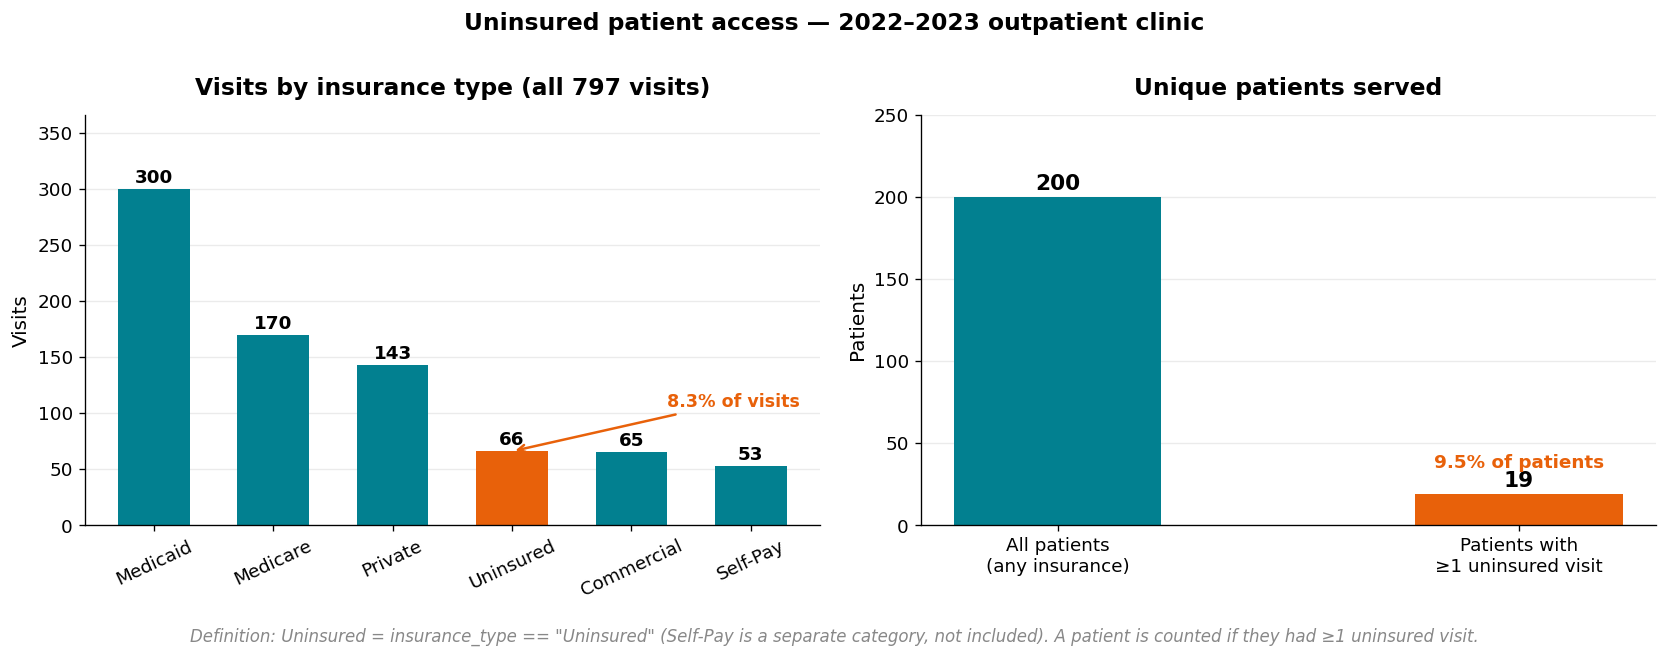

✓ Chart saved: share_chart3_uninsured.png


In [5]:
# ── Chart 3: Uninsured picture — for the funder ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: Visits by insurance type ─────────────────────────────────────────
ins_order = ins_counts.sort_values(ascending=False)
bar_colors_ins = [ORANGE if lbl == 'Uninsured' else TEAL for lbl in ins_order.index]
bars_ins = axes[0].bar(
    ins_order.index, ins_order.values,
    color=bar_colors_ins, width=0.6, zorder=2
)
axes[0].set_title('Visits by insurance type (all 797 visits)', pad=12)
axes[0].set_ylabel('Visits')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.25, zorder=1)
axes[0].set_ylim(0, ins_order.max() * 1.22)
for bar, val in zip(bars_ins, ins_order.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
        str(val), ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
# Arrow annotation on Uninsured bar
unins_bar_idx = list(ins_order.index).index('Uninsured')
axes[0].annotate(
    f'{pct_uninsured_vis:.1f}% of visits',
    xy=(unins_bar_idx, ins_order['Uninsured']),
    xytext=(unins_bar_idx + 1.3, ins_order['Uninsured'] + 40),
    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5),
    fontsize=10.5, color=ORANGE, fontweight='bold'
)

# ── Panel B: Unique patients served ───────────────────────────────────────────
groups = ['All patients\n(any insurance)', 'Patients with\n≥1 uninsured visit']
values = [n_patients, n_uninsured_pts]
bars_pts = axes[1].bar(groups, values, color=[TEAL, ORANGE], width=0.45, zorder=2)
axes[1].set_title('Unique patients served', pad=12)
axes[1].set_ylabel('Patients')
axes[1].grid(axis='y', alpha=0.25, zorder=1)
axes[1].set_ylim(0, n_patients * 1.25)
for bar, val in zip(bars_pts, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
        str(val), ha='center', va='bottom', fontsize=13, fontweight='bold'
    )
axes[1].text(
    1, n_uninsured_pts + n_patients * 0.08,
    f'{pct_uninsured_pts:.1f}% of patients',
    ha='center', fontsize=11, color=ORANGE, fontweight='bold'
)

# Definition footnote
fig.text(
    0.5, -0.04,
    'Definition: Uninsured = insurance_type == "Uninsured" (Self-Pay is a separate category, not included). '
    'A patient is counted if they had ≥1 uninsured visit.',
    ha='center', fontsize=10, color=MID, style='italic'
)

plt.suptitle(
    'Uninsured patient access — 2022–2023 outpatient clinic',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('share_chart3_uninsured.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved: share_chart3_uninsured.png")


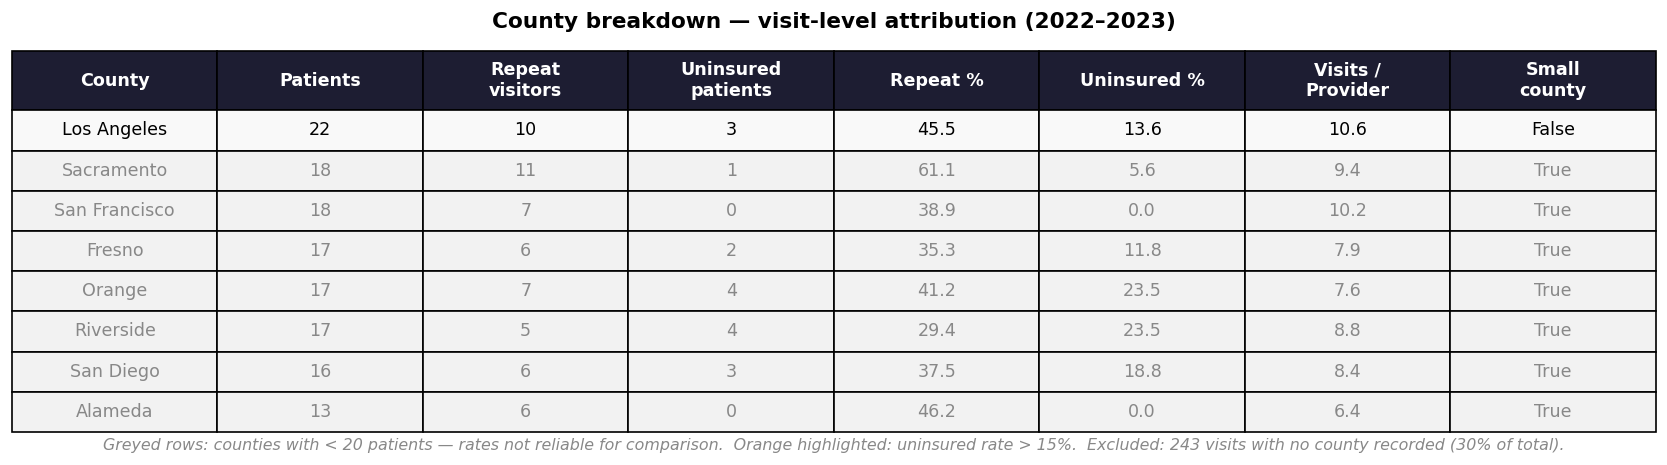

✓ Chart saved: share_chart4_county_table.png


In [6]:
# ── Chart 4: County breakdown table — for the funder ─────────────────────────
# A styled table is often more appropriate than a bar chart for data that
# the funder will reference row by row. The table goes into the report;
# the bar chart (below) goes into a presentation summary.

county_display = county_summary[[
    'county', 'total_patients', 'repeat_visitors', 'uninsured_patients',
    'repeat_rate', 'uninsured_rate', 'visits_per_provider', 'small_county'
]].copy()
county_display['repeat_rate']    = (county_display['repeat_rate']    * 100).round(1)
county_display['uninsured_rate'] = (county_display['uninsured_rate'] * 100).round(1)
county_display = county_display.sort_values('total_patients', ascending=False).reset_index(drop=True)

col_labels = ['County', 'Patients', 'Repeat\nvisitors', 'Uninsured\npatients',
              'Repeat %', 'Uninsured %', 'Visits /\nProvider', 'Small\ncounty']
cell_data   = county_display.values.tolist()

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axis('off')
table = ax.table(
    cellText=cell_data, colLabels=col_labels,
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)

for j in range(len(col_labels)):
    cell = table[(0, j)]
    cell.set_facecolor(DARK)
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_height(0.22)

for i in range(1, len(cell_data) + 1):
    row = county_display.iloc[i - 1]
    for j in range(len(col_labels)):
        cell = table[(i, j)]
        cell.set_height(0.15)
        if row['small_county']:
            cell.set_facecolor('#F2F2F2')
            cell.set_text_props(color=MID)
        elif j == 5 and float(row['uninsured_rate']) > 15:
            cell.set_facecolor('#FFF0E6')
            cell.set_text_props(color=ORANGE, fontweight='bold')
        else:
            cell.set_facecolor('#FFFFFF' if i % 2 == 0 else '#F9F9F9')

fig.text(
    0.5, 0.0,
    'Greyed rows: counties with < 20 patients — rates not reliable for comparison.  '
    'Orange highlighted: uninsured rate > 15%.  '
    f'Excluded: {n_county_excluded} visits with no county recorded ({n_county_excluded/n_visits*100:.0f}% of total).',
    ha='center', fontsize=9.5, color=MID, style='italic'
)
plt.title('County breakdown — visit-level attribution (2022–2023)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('share_chart4_county_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved: share_chart4_county_table.png")


---
## Part 2 — Written Summaries

### The key habit: provide verified numbers, prohibit additions

When asking AI to draft a written summary:

1. **Paste your verified numbers** explicitly into the prompt
2. **Tell AI to use only those numbers** — no statistics from its own knowledge
3. **Ask for a data limitation sentence** at the end

If AI includes a number you did not provide, remove it — do not correct it. AI generated that number on its own. It may look plausible. A number you cannot trace to your own analysis does not belong in a professional deliverable.

---

### What a hallucinated number looks like in practice

The practitioner asked AI to draft the staffing summary and got back this sentence (paraphrased):

> *"...averaging 4.0 visits per patient — nearly double the national average for community clinics."*

The number 4.0 came from the analysis. "Nearly double the national average" came from AI. The practitioner cannot verify that benchmark, cannot cite it, and cannot defend it to the board if challenged. It was removed.

AI also added this interpretive sentence:

> *"...suggesting that a meaningful share of returns reflect unresolved care rather than routine contact."*

The data shows the follow-up flag was set on the prior visit. It cannot confirm whether the return was caused by that flag — the patient might have returned for an entirely unrelated reason. An unsupported causal claim was removed.

**The rule:** A number or interpretation you cannot trace to your own verified output does not stay in the deliverable.


In [7]:
# ── Staffing brief — assembled from verified variables ────────────────────────
# Every number below traces directly to the analysis above.
# No AI-generated text is included — only the structure came from AI's draft.

top3 = top_conditions.head(3)

staffing_summary = f"""
STAFFING BRIEF — Clinic care coordinator decision
Dataset: Outpatient clinic, 2022–2023
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REPEAT VISIT PATTERN
The clinic served {n_patients} unique patients across {n_visits:,} visits over the
two-year period — an average of {n_visits/n_patients:.1f} visits per patient.

Of those patients, {n_repeat_30} ({pct_repeat_30:.0f}%) had at least one return visit
within 30 days. A further {freq_dist['4+×']} patients ({freq_dist['4+×']/n_patients*100:.0f}%)
visited four or more times across the period.

LINK TO UNRESOLVED CARE
Of the {n_return_visits} return visits that occurred within 30 days, {n_preceded}
({pct_preceded:.0f}%) were preceded by a visit where follow-up care had been flagged
as required.

The top three conditions among 30-day repeat visitors were:
  · {top3.iloc[0]['Diagnosis']} ({top3.iloc[0]['Visits']} visits)
  · {top3.iloc[1]['Diagnosis']} ({top3.iloc[1]['Visits']} visits)
  · {top3.iloc[2]['Diagnosis']} ({top3.iloc[2]['Visits']} visits)

All three are chronic conditions typically associated with ongoing care management needs.

GEOGRAPHIC RECOMMENDATION
The county-level ranking — which combined repeat visitor rate, uninsured burden,
and provider workload — identified {top_county} as the county with the highest
combined need. This is the recommended initial location for a care coordinator hire.

DATA LIMITATION
This analysis cannot confirm whether placing a care coordinator in {top_county}
would reduce repeat visits. A 12-month before-and-after evaluation would be required
to demonstrate impact.
"""

print(staffing_summary)



STAFFING BRIEF — Clinic care coordinator decision
Dataset: Outpatient clinic, 2022–2023
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REPEAT VISIT PATTERN
The clinic served 200 unique patients across 797 visits over the
two-year period — an average of 4.0 visits per patient.

Of those patients, 82 (41%) had at least one return visit
within 30 days. A further 110 patients (55%)
visited four or more times across the period.

LINK TO UNRESOLVED CARE
Of the 114 return visits that occurred within 30 days, 45
(39%) were preceded by a visit where follow-up care had been flagged
as required.

The top three conditions among 30-day repeat visitors were:
  · Essential Hypertension (51 visits)
  · Type 2 Diabetes without complications (47 visits)
  · Low Back Pain (41 visits)

All three are chronic conditions typically associated with ongoing care management needs.

GEOGRAPHIC RECOMMENDATION
The county-level ranking — which combined repeat visitor rate, uninsured burden,
and provider worklo

In [8]:
# ── Funding evidence summary — assembled from verified variables ───────────────
county_funder = county_summary[[
    'county', 'total_patients', 'uninsured_patients', 'uninsured_rate'
]].copy()
county_funder['uninsured_rate'] = (county_funder['uninsured_rate'] * 100).round(1)
county_funder = county_funder.sort_values('total_patients', ascending=False)
county_funder.columns = ['County', 'Total patients', 'Uninsured patients (≥1 visit)', 'Uninsured rate (%)']

funder_summary = f"""
FUNDING EVIDENCE SUMMARY — County access and equity report
Dataset: Outpatient clinic, 2022–2023
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DEFINITION
Uninsured = insurance_type recorded as "Uninsured".
Self-Pay is recorded as a separate category and is NOT included in this count.
A patient is counted as uninsured if they had at least one visit recorded with
Uninsured as the insurance type.

PATIENT VOLUME
During the two-year period, the clinic served {n_uninsured_pts} unique patients
who presented as uninsured in at least one visit. This represents
{pct_uninsured_pts:.1f}% of patients with a known insurance type
({n_patients} total patients in the dataset).

VISIT VOLUME
{uninsured_visits} clinic visits ({pct_uninsured_vis:.1f}% of all {n_visits:,} visits)
were recorded with Uninsured insurance type.

COUNTY BREAKDOWN (notes)
County-level figures use visit-level county attribution — each visit is counted
in the county where it was recorded. A patient who visited more than one county
is counted in each county where they presented; the sum of patients across counties
may therefore exceed total unique patients.

Seven of eight counties have fewer than 20 patients — rates for those counties
are not reliable for comparison and should not be used for funding allocation
decisions. County figures are provided for reference only.

{n_county_excluded} visits ({n_county_excluded/n_visits*100:.0f}% of total) had no
county recorded and are excluded from county-level calculations.
"""

print(funder_summary)
print("COUNTY DATA:")
print(county_funder.to_string(index=False))



FUNDING EVIDENCE SUMMARY — County access and equity report
Dataset: Outpatient clinic, 2022–2023
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DEFINITION
Uninsured = insurance_type recorded as "Uninsured".
Self-Pay is recorded as a separate category and is NOT included in this count.
A patient is counted as uninsured if they had at least one visit recorded with
Uninsured as the insurance type.

PATIENT VOLUME
During the two-year period, the clinic served 19 unique patients
who presented as uninsured in at least one visit. This represents
9.5% of patients with a known insurance type
(200 total patients in the dataset).

VISIT VOLUME
66 clinic visits (8.3% of all 797 visits)
were recorded with Uninsured insurance type.

COUNTY BREAKDOWN (notes)
County-level figures use visit-level county attribution — each visit is counted
in the county where it was recorded. A patient who visited more than one county
is counted in each county where they presented; the sum of patients across count

---
## Part 3 — Bias and Equity Checks

A clinical dataset can reveal whether certain patient groups are missing from the data, whether access to care differs across demographics, or whether any providers carry disproportionate shares of uninsured patients. Sharing findings without checking for these patterns is a professional failure — the people receiving the deliverable cannot spot what the analyst did not look for.

### The practitioner's AI prompt for the checklist

> *"I have a clinical outpatient visit dataset with 797 visits across 2022–2023. Columns include: patient ID, visit date, diagnosis code, visit type, gender, age, insurance type (Medicaid, Medicare, Private, Uninsured, Commercial, Self-Pay), provider ID, county, copay amount, follow-up required. What types of bias or equity concerns should I check for before sharing findings with a clinic director and a county funder? Give me 5 specific checks — for each, describe the concern, how to detect it in this data, and why it matters."*

AI returned a structured checklist of five checks. The practitioner ran each one below. AI found the questions. The practitioner found the answers.


In [9]:
# ── Check 1: Missing data concentration ──────────────────────────────────────
print("CHECK 1: Missing data — is it concentrated in any group?")
print("─" * 60)

# Overall missing data
missing_by_col = df.isnull().sum()
missing_pct    = (missing_by_col / len(df) * 100).round(1)
missing_report = pd.DataFrame({'Missing rows': missing_by_col, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing rows'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:")
print(missing_report.to_string())

# County missingness by insurance type — key equity check
print("\nCounty data missing by insurance type:")
county_miss_by_ins = df.groupby('insurance_type').apply(
    lambda x: (x['county_known'] == False).sum() / len(x) * 100
).round(1).sort_values(ascending=False)
for ins, pct in county_miss_by_ins.items():
    flag = '  ⚠' if pct > 40 else ''
    print(f"  {ins:<15}  {pct:>5.1f}% county missing{flag}")

print("\n→ If any group has much higher county missingness, that group is")
print("  underrepresented in county-level reports — note in the funder summary.")


CHECK 1: Missing data — is it concentrated in any group?
────────────────────────────────────────────────────────────
Columns with missing values:
                 Missing rows  Missing %
county                    243       30.5
copay_amount               58        7.3
age                        43        5.4
icd_code                   28        3.5
icd_description            28        3.5
visit_date                  4        0.5

County data missing by insurance type:
  Commercial        47.7% county missing  ⚠
  Medicaid          35.7% county missing
  Private           28.7% county missing
  Medicare          26.5% county missing
  Self-Pay          20.8% county missing
  Uninsured         12.1% county missing

→ If any group has much higher county missingness, that group is
  underrepresented in county-level reports — note in the funder summary.


In [10]:
# ── Check 2: Access patterns by insurance type ───────────────────────────────
print("CHECK 2: Access pattern differences by insurance type")
print("─" * 60)

# Follow-up flag rate by insurance type
fu_by_ins = df_sorted.groupby('insurance_type')['followup_flag'].mean().sort_values(ascending=False)
print("Follow-up flagged rate by insurance type:")
for ins, rate in fu_by_ins.items():
    bar = '█' * int(rate * 30)
    print(f"  {ins:<15} {rate*100:>5.1f}%  {bar}")

# Telehealth access by insurance type (proxy for remote access)
print("\nTelehealth share by insurance type (proxy for digital access):")
tele_by_ins = df.groupby('insurance_type').apply(
    lambda x: (x['visit_type'] == 'Telehealth').mean() * 100
).round(1).sort_values(ascending=False)
for ins, pct in tele_by_ins.items():
    print(f"  {ins:<15} {pct:>5.1f}%")

max_tele = tele_by_ins.max(); min_tele = tele_by_ins.min()
if max_tele - min_tele > 15:
    print("\n⚠ Significant variation in telehealth access across insurance types.")
    print("  → May indicate digital access barriers for some groups.")
else:
    print("\n✓ Telehealth access is broadly consistent across insurance types.")


CHECK 2: Access pattern differences by insurance type
────────────────────────────────────────────────────────────
Follow-up flagged rate by insurance type:
  Uninsured        43.9%  █████████████
  Self-Pay         37.7%  ███████████
  Medicaid         37.7%  ███████████
  Medicare         37.1%  ███████████
  Private          29.4%  ████████
  Commercial       27.7%  ████████

Telehealth share by insurance type (proxy for digital access):
  Private          32.9%
  Self-Pay         32.1%
  Medicare         25.9%
  Uninsured        25.8%
  Medicaid         20.3%
  Commercial       18.5%

✓ Telehealth access is broadly consistent across insurance types.


In [11]:
# ── Check 3: Provider workload disparity ─────────────────────────────────────
print("CHECK 3: Are uninsured patients concentrated with specific providers?")
print("─" * 60)

provider_summary = df.groupby('provider_id').agg(
    total_visits=('visit_id', 'count'),
    uninsured_visits=('is_uninsured_visit', 'sum'),
).reset_index()
provider_summary['uninsured_pct'] = (
    provider_summary['uninsured_visits'] / provider_summary['total_visits'] * 100
).round(1)
provider_summary = provider_summary.sort_values('uninsured_pct', ascending=False)
print(provider_summary.to_string(index=False))

max_u = provider_summary['uninsured_pct'].max()
min_u = provider_summary['uninsured_pct'].min()
print(f"\nUninsured visit share range: {min_u:.1f}% – {max_u:.1f}%")
if max_u - min_u > 10:
    print("⚠ Uninsured patients are not evenly distributed across providers.")
    print("  → Worth investigating whether this is by assignment or by patient choice.")
else:
    print("✓ Uninsured patient load is broadly even across providers.")


CHECK 3: Are uninsured patients concentrated with specific providers?
────────────────────────────────────────────────────────────
provider_id  total_visits  uninsured_visits  uninsured_pct
       DR07            95                11           11.6
       DR04            98                11           11.2
       DR05            90                10           11.1
       DR06            98                 9            9.2
       DR03           102                 7            6.9
       DR01           108                 7            6.5
       DR08           109                 7            6.4
       DR02            97                 4            4.1

Uninsured visit share range: 4.1% – 11.6%
✓ Uninsured patient load is broadly even across providers.


In [12]:
# ── Check 4: Age group representation ────────────────────────────────────────
print("CHECK 4: Is any age group underrepresented?")
print("─" * 60)

age_groups = pd.cut(
    df['age'], bins=[0, 17, 35, 50, 65, 120],
    labels=['Under 18', '18–35', '36–50', '51–65', '65+']
)
age_dist = age_groups.value_counts(sort=False)
print("Visits by age group:")
for group, count in age_dist.items():
    bar = '█' * int(count / len(df) * 40)
    print(f"  {group:<10} {count:>4} visits ({count/len(df)*100:>5.1f}%)  {bar}")

missing_age  = df['age'].isna().sum()
invalid_age  = ((df['age'] < 0) | (df['age'] > 120)).sum()
print(f"\nMissing age values: {missing_age}")
print(f"Invalid age values:  {invalid_age}")
print("\n→ Compare to the clinic's service area demographics if available.")
print("  A very small under-18 share may indicate a gap in paediatric access data.")


CHECK 4: Is any age group underrepresented?
────────────────────────────────────────────────────────────
Visits by age group:
  Under 18      0 visits (  0.0%)  
  18–35       211 visits ( 26.5%)  ██████████
  36–50       151 visits ( 18.9%)  ███████
  51–65       150 visits ( 18.8%)  ███████
  65+         242 visits ( 30.4%)  ████████████

Missing age values: 43
Invalid age values:  0

→ Compare to the clinic's service area demographics if available.
  A very small under-18 share may indicate a gap in paediatric access data.


In [13]:
# ── Check 5: Follow-up completion — do patients who need follow-up return? ────
print("CHECK 5: Follow-up completion gap by insurance type")
print("─" * 60)
print("Do patients who were flagged for follow-up actually return within 60 days?")
print()

# Mark whether each flagged visit was followed by a return within 60 days
flagged_visits = df_sorted[df_sorted['followup_flag'] == True].copy()
flagged_visits['next_visit_date'] = flagged_visits.groupby('patient_id')['visit_date'].shift(-1)
flagged_visits['days_to_next']    = (flagged_visits['next_visit_date'] - flagged_visits['visit_date']).dt.days
flagged_visits['returned_60d']    = flagged_visits['days_to_next'] <= 60

fu_completion = flagged_visits.groupby('insurance_type')['returned_60d'].agg(
    flagged_visits='count',
    returned_60d='sum'
).reset_index()
fu_completion['return_rate_pct'] = (
    fu_completion['returned_60d'] / fu_completion['flagged_visits'] * 100
).round(1)
fu_completion = fu_completion.sort_values('return_rate_pct', ascending=False)
fu_completion.columns = ['Insurance type', 'Flagged visits', 'Returned within 60d', 'Return rate (%)']

print(fu_completion.to_string(index=False))

max_r = fu_completion['Return rate (%)'].max()
min_r = fu_completion['Return rate (%)'].min()
print(f"\nReturn rate range: {min_r:.1f}% – {max_r:.1f}%")
if max_r - min_r > 15:
    print("⚠ Significant gap in follow-up completion across insurance types.")
    print("  → Patients with lower completion rates may face access or cost barriers.")
    print("  → Consider flagging this finding for both the board and the funder.")
else:
    print("✓ Follow-up completion is broadly consistent across insurance types.")


CHECK 5: Follow-up completion gap by insurance type
────────────────────────────────────────────────────────────
Do patients who were flagged for follow-up actually return within 60 days?

Insurance type  Flagged visits  Returned within 60d  Return rate (%)
     Uninsured              29                    6             20.7
      Medicare              63                    8             12.7
    Commercial              18                    2             11.1
      Medicaid             113                   12             10.6
      Self-Pay              20                    2             10.0
       Private              42                    4              9.5

Return rate range: 9.5% – 20.7%
✓ Follow-up completion is broadly consistent across insurance types.


---
## Part 4 — The Deliverable

The cells above have produced every component of the two deliverables. This final cell assembles a complete printout — ready to copy into a report, paste into a slide, or pipe into an automated document generator.

Every number traces to the analysis. Every interpretation is bounded by what the data can confirm. Every limitation is stated where the audience will see it.


In [14]:
# ── Complete deliverable output ───────────────────────────────────────────────
banner = "=" * 70

print(banner)
print("DELIVERABLE 1 OF 2 — STAFFING BRIEF")
print(banner)
print(staffing_summary)

print()
print(banner)
print("DELIVERABLE 2 OF 2 — FUNDING EVIDENCE SUMMARY")
print(banner)
print(funder_summary)
print("COUNTY DATA:")
print(county_funder.to_string(index=False))

print()
print("─" * 70)
print("CHARTS PRODUCED (saved to /home/claude/):")
for name, desc in [
    ('share_chart1_repeat_scale.png', 'Repeat visit pattern         → board presentation'),
    ('share_chart2_followup.png',     'Follow-up linkage + conditions → board presentation'),
    ('share_chart3_uninsured.png',    'Uninsured access breakdown   → funder report'),
    ('share_chart4_county_table.png', 'County breakdown table       → funder report'),
]:
    print(f"  {name:<38}  {desc}")


DELIVERABLE 1 OF 2 — STAFFING BRIEF

STAFFING BRIEF — Clinic care coordinator decision
Dataset: Outpatient clinic, 2022–2023
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REPEAT VISIT PATTERN
The clinic served 200 unique patients across 797 visits over the
two-year period — an average of 4.0 visits per patient.

Of those patients, 82 (41%) had at least one return visit
within 30 days. A further 110 patients (55%)
visited four or more times across the period.

LINK TO UNRESOLVED CARE
Of the 114 return visits that occurred within 30 days, 45
(39%) were preceded by a visit where follow-up care had been flagged
as required.

The top three conditions among 30-day repeat visitors were:
  · Essential Hypertension (51 visits)
  · Type 2 Diabetes without complications (47 visits)
  · Low Back Pain (41 visits)

All three are chronic conditions typically associated with ongoing care management needs.

GEOGRAPHIC RECOMMENDATION
The county-level ranking — which combined repeat visitor rate, u

---
## Extension — automated output formats

This notebook produced structured text and PNG charts. The same content can be rendered into other formats automatically. Students are encouraged to explore at least one of these extensions.

| Format | Library | What it adds |
|---|---|---|
| Formatted HTML report | `jinja2` + matplotlib | A self-contained `.html` file with embedded charts — shareable by email |
| Word document | `python-docx` | A `.docx` the director can edit, mark up, and circulate internally |
| PowerPoint deck | `python-pptx` or `pptxgenjs` | Chart images on pre-styled slide layouts |
| PDF | `matplotlib` PDF backend or `weasyprint` | A print-ready document with consistent pagination |

The content does not change. The rendering layer does. Accuracy, honesty, and actionability apply regardless of format.

A practical starting point for the HTML route:

```python
# pip install jinja2
from jinja2 import Template
import base64, pathlib

def img_b64(path):
    return base64.b64encode(pathlib.Path(path).read_bytes()).decode()

template = Template("""
<html><body>
<h1>Clinic Staffing Brief — 2022–2023</h1>
<img src='data:image/png;base64,{{ chart1 }}' width='800'>
<pre>{{ summary }}</pre>
</body></html>
""")

html = template.render(
    chart1=img_b64('/home/claude/share_chart1_repeat_scale.png'),
    summary=staffing_summary
)
pathlib.Path('/home/claude/staffing_brief.html').write_text(html)
```


---
## Practitioner reflection

### Where human judgement shaped the SHARE step

**1. Removing a benchmark AI added**
AI inserted "nearly double the national average for community clinics" into the staffing summary. This was removed — not corrected. A benchmark the practitioner cannot verify, cite, and defend under questioning has no place in a board deliverable, however plausible it sounds.

**2. Removing an unsupported causal claim**
AI wrote that repeat visits "suggest unresolved care rather than routine contact." The data shows the follow-up flag was set. It cannot show why the patient returned. The sentence was removed — not softened. Softening would have left the implication. Removing it was the honest choice.

**3. Keeping the definition explicit in the funder summary**
The uninsured patient definition — what counts, what does not, and why — was written into the funder summary as its own labelled section. AI's draft buried this in a footnote. The practitioner moved it up because the funder will be questioned on this number and needs the definition immediately visible, not discoverable at the bottom of the page.

**4. Reporting limitations prominently**
The practitioner included the county exclusion figure (243 visits, 30.5% of total) in the main body of the funder summary, not as a footnote. A limitation this significant belongs where the audience cannot miss it.

---

> *Charts, summaries, and bias checks were all produced with AI assistance. The practitioner filled in verified numbers, removed two AI-generated additions, moved one critical definition, and decided how prominently to surface the data limitation. That is the work of SHARE.*

---
*Module 3 · AI-Enabled Data Practitioner Course · Outpatient Visits Dataset*
